In [2]:
import tensorflow as tf
import os
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input


SEED=42
tf.random.set_seed(SEED)

IMG_SIZE=(300,300)
BATCH_SIZE=64


DATASET_PATH="/kaggle/input/balanced-dataset-of-pest/Balanced_Dataset_Of_Pest"

In [3]:
import os
import pandas as pd

class_labels = []

# Check what folders are in the dataset
dataset_path = "/kaggle/input/balanced-dataset-of-pest/Balanced_Dataset_Of_Pest"
folders = os.listdir(dataset_path)
print("Available folders:", folders)

for folder in folders:
    images = os.listdir(os.path.join(dataset_path, folder))
    for img in images:
        class_labels.append((folder, os.path.join(dataset_path, folder, img)))

df = pd.DataFrame(class_labels, columns=['Labels', 'image'])
print(df.head(10))
print(df.tail(10))


Available folders: ['beetle', 'bugs', 'mites', 'grasshopper', 'earwig', 'snail', 'catterpillar', 'weevil', 'whitefly', 'aphids', 'slug', 'bollworm']
   Labels                                              image
0  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
1  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
2  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
3  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
4  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
5  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
6  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
7  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
8  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
9  beetle  /kaggle/input/balanced-dataset-of-pest/Balance...
        Labels                                              image
8390  bollworm  /kaggle/input/balanced-dataset-of-pest/Balance...
8391  bollworm  /kaggle/input/balanced-dataset-o

In [4]:
print("Total number of images in dataset: ",len(df))

label_count=df['Labels'].value_counts()
print(label_count)

Total number of images in dataset:  8400
Labels
beetle          700
bugs            700
mites           700
grasshopper     700
earwig          700
snail           700
catterpillar    700
weevil          700
whitefly        700
aphids          700
slug            700
bollworm        700
Name: count, dtype: int64


In [5]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 8400 files belonging to 12 classes.
Using 6720 files for training.


I0000 00:00:1767177334.451670      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767177334.455655      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 8400 files belonging to 12 classes.
Using 1680 files for validation.


In [6]:
val_batches = int(0.5 * tf.data.experimental.cardinality(val_test_ds).numpy())
val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)


In [7]:
class_names=train_ds.class_names
NUM_CLASSES=len(class_names)

print("Classes: ", class_names)
print("Total classes: ",NUM_CLASSES)

Classes:  ['aphids', 'beetle', 'bollworm', 'bugs', 'catterpillar', 'earwig', 'grasshopper', 'mites', 'slug', 'snail', 'weevil', 'whitefly']
Total classes:  12


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


In [9]:
from tensorflow.keras import layers

data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.33),
    #layers.RandomContrast(0.40),
    #layers.RandomBrightness(0.20),
],name="data_augmentation")

In [10]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


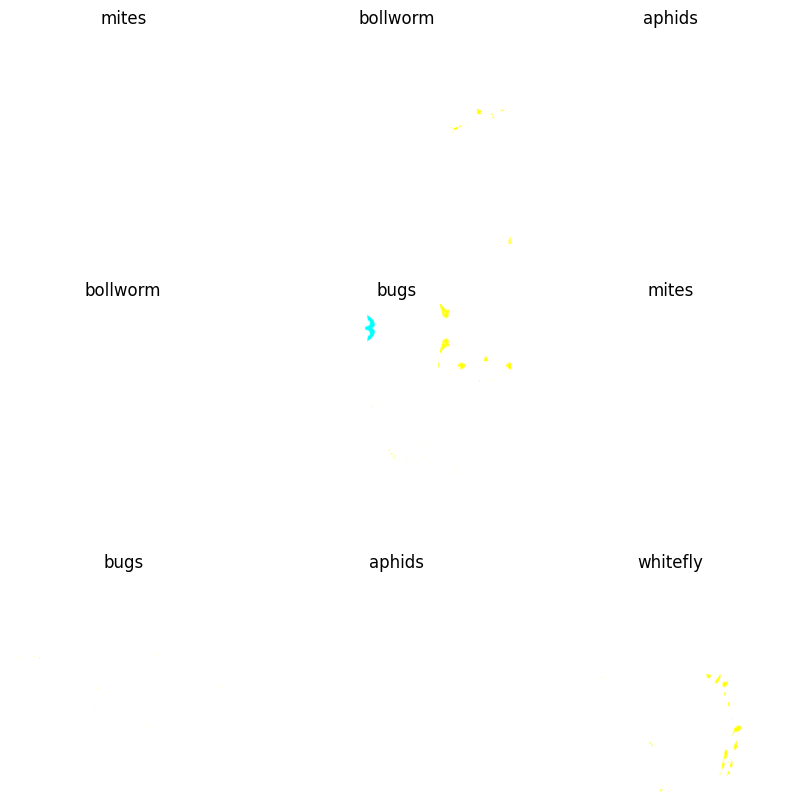

In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf

image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    
    # Clip values ONLY for visualization
    img = tf.clip_by_value(image_batch[i], 0.0, 1.0)
    
    plt.imshow(img.numpy())
    plt.title(class_names[label_batch[i]])
    plt.axis("off")

plt.show()


Found 8400 files belonging to 12 classes.


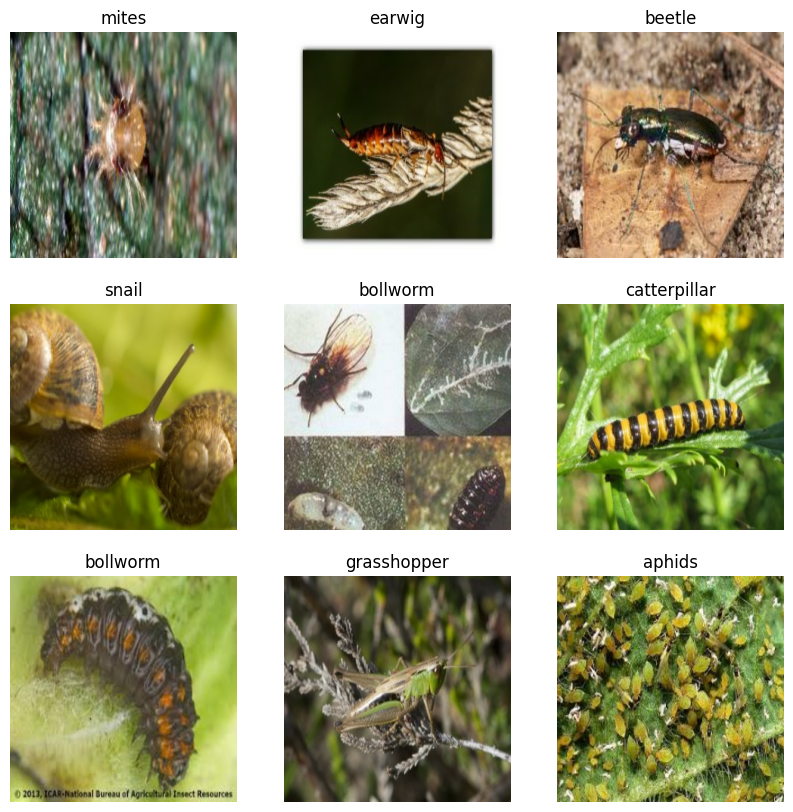

In [12]:
raw_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SIZE,
    batch_size=9,
    shuffle=True
)

raw_images, raw_labels = next(iter(raw_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(raw_images[i].numpy().astype("uint8"))
    plt.title(class_names[raw_labels[i]])
    plt.axis("off")


In [13]:
base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300, 300, 3)
)

# Freeze backbone
base_model.trainable = False


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
from tensorflow.keras import layers, models

def HybridPestNet(num_classes):
    inputs = layers.Input(shape=(300, 300, 3))

    # Data augmentation
    x = data_augmentation(inputs)

    # Preprocessing for EfficientNet
    x = preprocess_input(x)

    # Backbone feature extractor
    x = base_model(x, training=False)
    # --- REFINED HEAD ---
    # 1. Spatial Feature Compression
    x = layers.SeparableConv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # 2. Global Pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # 3. Dense Neck with Internal Normalization
    x = layers.Dense(256)(x) # Reduced from 512 to prevent overfitting
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.4)(x) # Slightly lower dropout for better convergence

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="HybridPestNet")
    return model


In [15]:
model = HybridPestNet(NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0003),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


Model: "HybridPestNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 10, 10, 256)    │       407,040 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,261,499 (42.96 MB)

 Trainable params: 476,940 (1.82 MB)

 Non-trainable params: 10,784,559 (41.14 MB)

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [17]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    min_lr=1e-6
)


In [18]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_pestnet.keras",
    monitor="val_accuracy",
    save_best_only=True
)


In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/25


E0000 00:00:1767177381.744349      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/HybridPestNet_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1767177386.100298     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


105/105 ━━━━━━━━━━━━━━━━━━━━ 105s 782ms/step - accuracy: 0.4577 - loss: 1.7407 - val_accuracy: 0.0853 - val_loss: 2.3528 - learning_rate: 3.0000e-04
Epoch 2/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 666ms/step - accuracy: 0.7400 - loss: 0.8328 - val_accuracy: 0.0877 - val_loss: 2.1268 - learning_rate: 3.0000e-04
Epoch 3/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 666ms/step - accuracy: 0.7716 - loss: 0.7191 - val_accuracy: 0.5096 - val_loss: 1.4917 - learning_rate: 3.0000e-04
Epoch 4/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 663ms/step - accuracy: 0.8035 - loss: 0.6130 - val_accuracy: 0.8149 - val_loss: 0.7132 - learning_rate: 3.0000e-04
Epoch 5/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 664ms/step - accuracy: 0.8216 - loss: 0.5516 - val_accuracy: 0.8810 - val_loss: 0.4155 - learning_rate: 3.0000e-04
Epoch 6/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 666ms/step - accuracy: 0.8257 - loss: 0.5411 - val_accuracy: 0.8942 - val_loss: 0.3584 - learning_rate: 3.0000e-04
Epoch 7/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 665ms/step -

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 514ms/step - accuracy: 0.9232 - loss: 0.2890
Test Accuracy: 92.10%
Test Loss: 0.3088


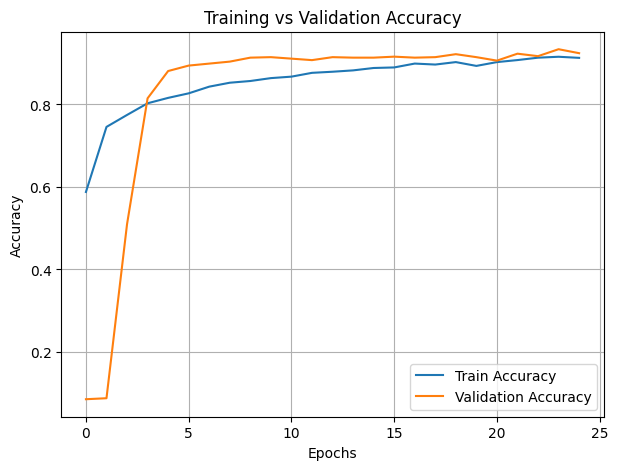

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


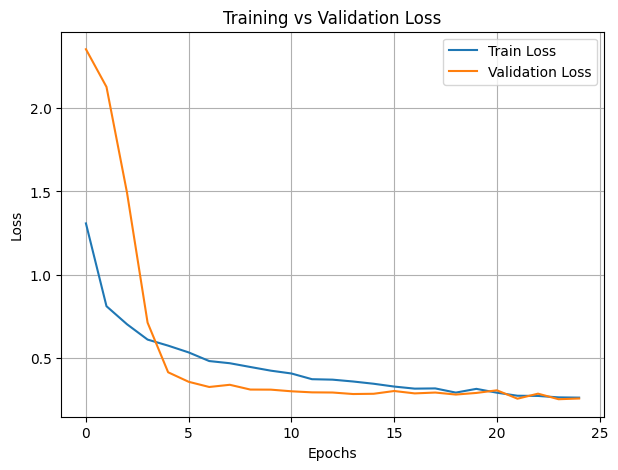

In [22]:
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)


              precision    recall  f1-score   support

      aphids       0.78      0.89      0.83        63
      beetle       0.90      0.80      0.85        66
    bollworm       0.90      0.97      0.94        67
        bugs       0.90      0.95      0.93        60
catterpillar       0.94      0.84      0.89        79
      earwig       0.95      0.88      0.91        59
 grasshopper       1.00      0.96      0.98        73
       mites       0.96      0.92      0.94        85
        slug       0.94      0.96      0.95        68
       snail       0.98      1.00      0.99        65
      weevil       0.91      0.98      0.94        87
    whitefly       0.88      0.91      0.90        76

    accuracy                           0.92       848
   macro avg       0.92      0.92      0.92       848
weighted avg       0.92      0.92      0.92       848



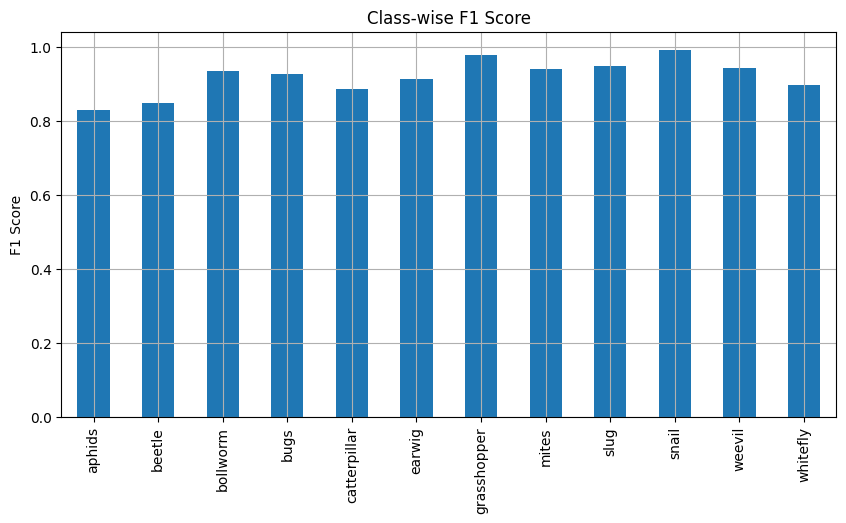

In [25]:
import pandas as pd

report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

df = pd.DataFrame(report_dict).transpose()

df["f1-score"][:-3].plot(
    kind="bar", figsize=(10,5), title="Class-wise F1 Score"
)
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()


<Figure size 1000x1000 with 0 Axes>

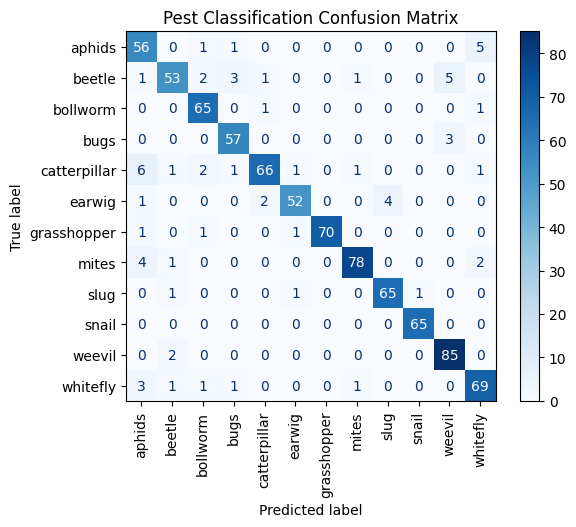

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Pest Classification Confusion Matrix")
plt.show()


In [27]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)


**testing phase**

In [28]:
import tensorflow as tf
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications.efficientnet import preprocess_input


In [29]:
# Load model
model = tf.keras.models.load_model("/kaggle/working/best_pestnet.keras")

# Load class names
with open("/kaggle/working/class_names.json", "r") as f:
    class_names = json.load(f)

print(class_names)


['aphids', 'beetle', 'bollworm', 'bugs', 'catterpillar', 'earwig', 'grasshopper', 'mites', 'slug', 'snail', 'weevil', 'whitefly']


In [30]:
IMG_SIZE = (300, 300)

def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img)
    img = preprocess_input(img)
    return np.expand_dims(img, axis=0)


In [31]:
def predict_folder(folder, threshold=0.65):
    images = []
    filenames = []

    print("Scanning folder:", folder)

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                path = os.path.join(root, file)
                try:
                    img = preprocess_image(path)
                    images.append(img)
                    filenames.append(file)
                except Exception as e:
                    print("❌ Failed to load:", file, e)

    if len(images) == 0:
        raise ValueError(
            f"No valid images found in folder: {folder}\n"
            "Check dataset path and image extensions."
        )

    images = np.vstack(images)
    preds = model.predict(images)

    results = []
    for i, pred in enumerate(preds):
        idx = np.argmax(pred)
        conf = float(np.max(pred))
        label = class_names[idx] if conf >= threshold else "Uncertain"
        results.append((filenames[i], label, conf))

    return results


In [32]:
TEST_DIR = "/kaggle/input/real-test-images2/real-test-images"
results = predict_folder(TEST_DIR)

results


Scanning folder: /kaggle/input/real-test-images2/real-test-images
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step


[('138_th15.jpg', 'whitefly', 0.9831477403640747),
 ('105_61125.jpg', 'whitefly', 0.9930180311203003),
 ('aug_64.jpg', 'Uncertain', 0.3954146206378937),
 ('88_Squash Bug_353.jpg', 'bugs', 0.9998664855957031),
 ('81_IMG_4667-495x400.jpg', 'whitefly', 0.9899964332580566),
 ('13_earwig (218).jpg', 'earwig', 0.90496426820755),
 ('5_61440.jpg', 'whitefly', 0.999987006187439),
 ('22_earwig (284).jpg', 'earwig', 0.9706341028213501),
 ('ece7ccd75fef4f2bbd8e7615f42f0a54.webp', 'slug', 0.999930739402771),
 ('87_Squash Bug_373.jpg', 'bugs', 0.9999994039535522),
 ('aedes-sp-mosquitoes-are-active-during-the-daytime-show-aggressive-human-biting-behavior-and.webp',
  'bugs',
  0.6851070523262024),
 ('360_F_226506802_EOAkNUEDYi0zG4LNgJTyS0VNIFos3CX7.webp',
  'Uncertain',
  0.478858083486557),
 ('48_earwig (323).jpg', 'earwig', 0.9969719648361206),
 ('21_Boxelder Bugs_241.jpg', 'bugs', 0.9999954700469971),
 ('69_61079.jpg', 'whitefly', 0.9471081495285034),
 ('aug_27.jpg', 'bugs', 0.9891424775123596),
 

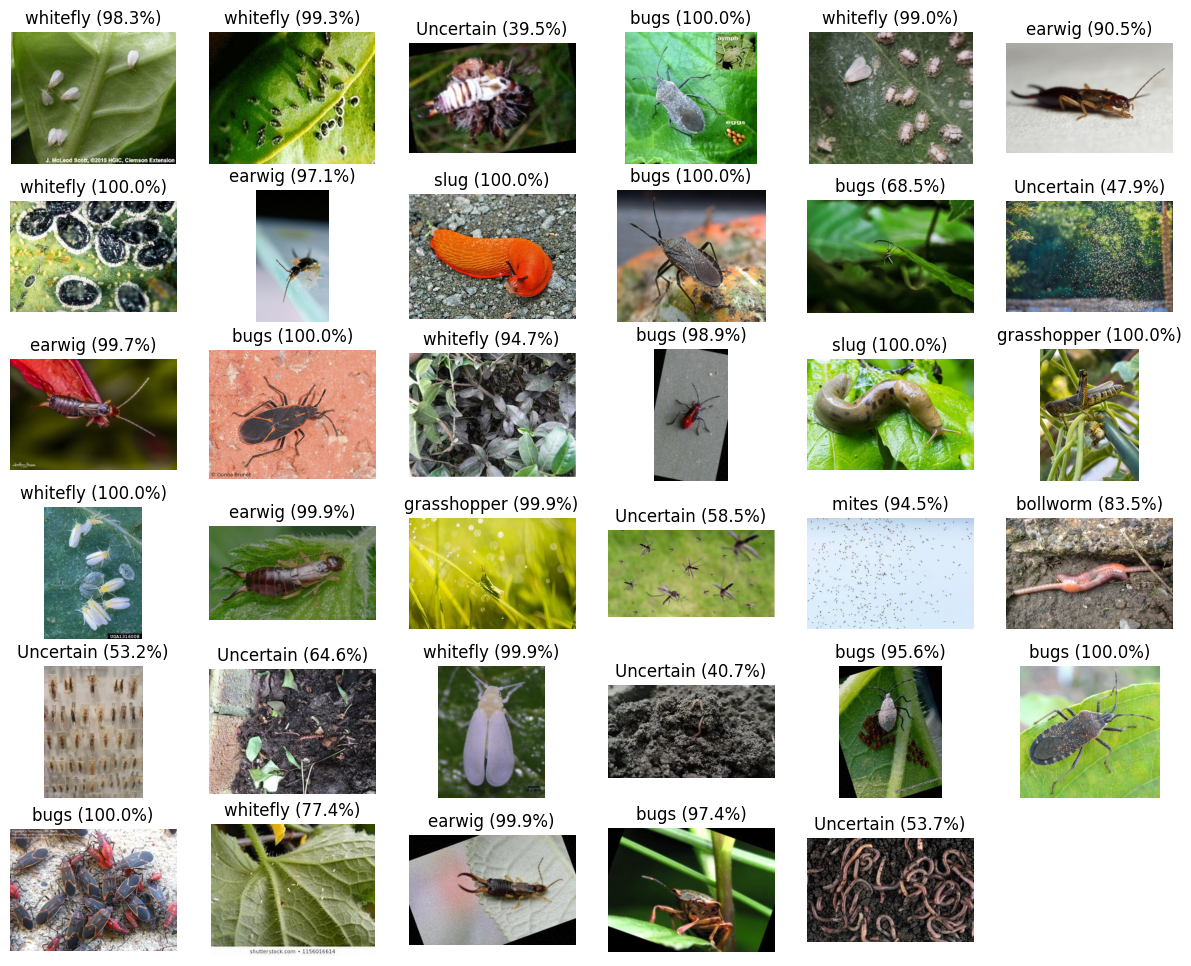

In [33]:
plt.figure(figsize=(15, 12))

for i, (fname, label, conf) in enumerate(results):
    img = Image.open(os.path.join(TEST_DIR, fname))
    plt.subplot(6, 6, i+1)
    plt.imshow(img)
    plt.title(f"{label} ({conf*100:.1f}%)")
    plt.axis("off")

plt.show()


In [34]:
model = HybridPestNet(19)
model.summary()

Model: "HybridPestNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 10, 10, 256)    │       407,040 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,263,298 (42.97 MB)

 Trainable params: 478,739 (1.83 MB)

 Non-trainable params: 10,784,559 (41.14 MB)

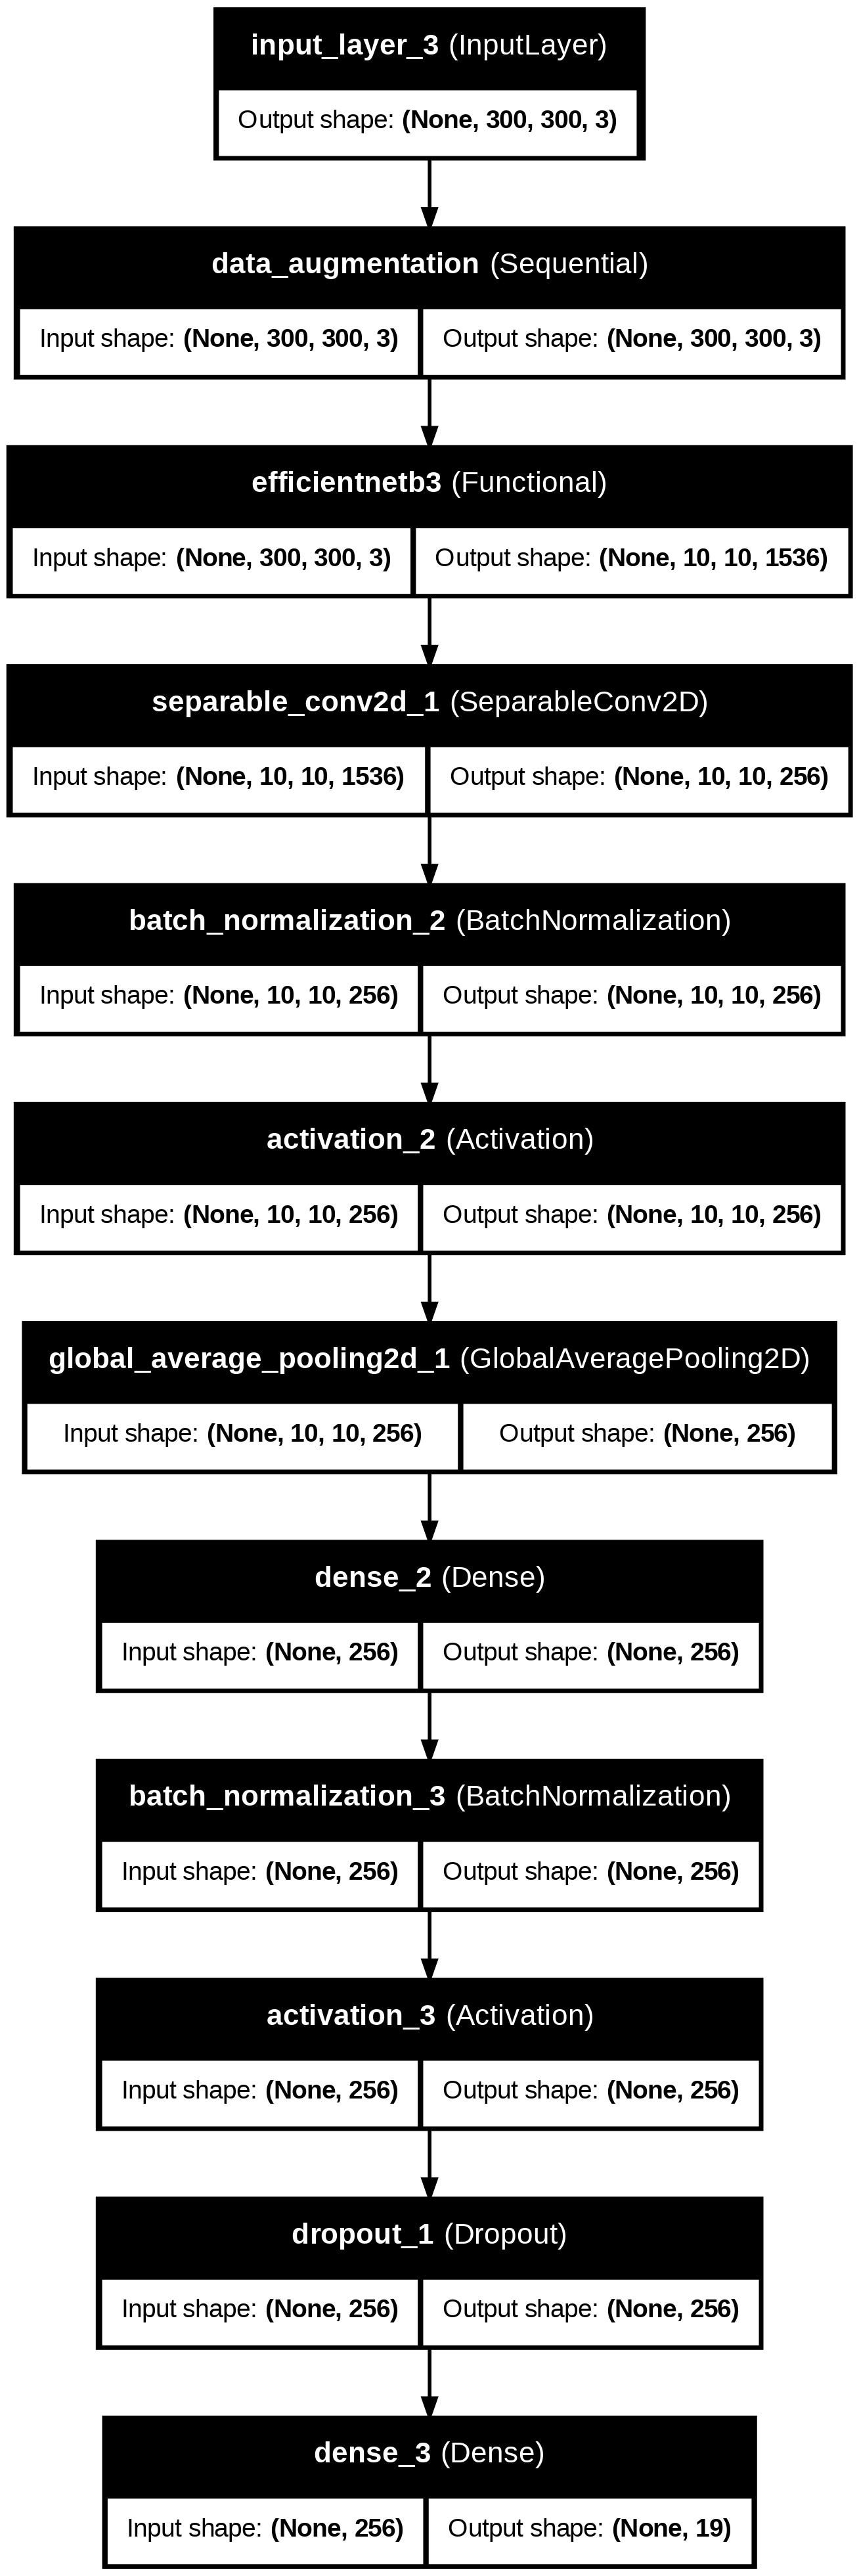

In [35]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='hybrid_pest_net.png', show_shapes=True, show_layer_names=True)

# **Unfree the base Model for some epochs**

In [39]:
# 1. Unfreeze ONLY the last few layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-20]: # Keep everything except the last 20 layers frozen
    layer.trainable = False

# 2. Keep BatchNormalization layers frozen (Crucial for stability!)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# 3. Re-compile with the tiny learning rate
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# 4. Final training (Use a batch size of 8 or 16 if it crashes)
history_final = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10


E0000 00:00:1767179755.424951      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/HybridPestNet_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


ResourceExhaustedError: Graph execution error:

Detected at node HybridPestNet_1/efficientnetb3_1/block7b_activation_1/Sigmoid defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  Fi

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\n--- Final Results ---")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history_fine.history["accuracy"], label="Train Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(7,5))
plt.plot(history_fine.history["loss"], label="Train Loss")
plt.plot(history_fine.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Pest Classification Confusion Matrix")
plt.show()
